Descripción del Dataset

Este dataset proviene de la Encuesta de Movilidad de Bogotá (Kaggle: eduarmma19/movilidad-de-bogot-caracterizacin-viajes). Contiene **147.251 viajes** con **33 columnas**, incluyendo:

- **Motivos**: Volver a casa (48.18%), Trabajar (19.32%).
- **Tiempos**: Mediana de 5 min en TIEMPOCAMINO.
- **Modos**: PEATON (47k), TPC-SITP (28k), Transmilenio (16k).
- **Geolocalización**: LATITUD/LONGITUD origen-destino.
- **Factores**: Ponderadores para análisis representativos.

In [ ]:
import kagglehub

# Descargando la ultima versión del DataSet
path = kagglehub.dataset_download("eduarmma19/movilidad-de-bogot-caracterizacin-viajes")

print("Path to dataset files:", path)




Using Colab cache for faster access to the 'movilidad-de-bogot-caracterizacin-viajes' dataset.
Path to dataset files: /kaggle/input/movilidad-de-bogot-caracterizacin-viajes


Se procederá a descargar el dataset, asi como la lectura de este.

In [ ]:
import os
import pandas as pd

csv_path = os.path.join(path, "Encuesta_movilidad.csv")
print("Ruta completa al CSV:", csv_path)

#Lectura
df = pd.read_csv(
    csv_path,
    encoding="latin1",
    sep=","
)
#muestra los 5 primeros registros y el tamaño del dataset
print("Shape (filas, columnas):", df.shape)
print(df.head())
print(df.info())


Ruta completa al CSV: /kaggle/input/movilidad-de-bogot-caracterizacin-viajes/Encuesta_movilidad.csv
Shape (filas, columnas): (147251, 33)
   ID_ENCUESTA  NUMERO_PERSONA  NUMERO_VIAJE    MOTIVOVIAJE MUNICIPIO_DESTINO  \
0     18390069               2             1       Tramites   BOGOTA-DC 11001   
1     18390069               2             2  Volver a casa   BOGOTA-DC 11001   
2     18390069               3             1       Estudiar   BOGOTA-DC 11001   
3     18390069               3             2  Volver a casa   BOGOTA-DC 11001   
4     18390891               1             1       Trabajar   BOGOTA-DC 11001   

  DEPARTAMENTO_DESTINO  TIEMPO_CAMINO HORA_INICIO  HORA_FIN  \
0          Bogota D.C.           10.0    08:05:00  09:55:00   
1          Bogota D.C.           10.0    10:21:05  12:11:05   
2          Bogota D.C.           10.0    06:27:00  06:45:00   
3          Bogota D.C.           10.0    08:46:27  09:41:27   
4          Bogota D.C.            7.0    07:47:00  09:19:00 

Análisis Exploratorio

- Análisis exploratorio univariado de la columna MOTIVOVIAJE en el dataset de movilidad de Bogotá, calculando frecuencias absolutas  y generando un gráfico de barras horizontales con matplotlib para visualizar la distribución de motivos de viaje,

Frecuencia de motivos de viaje:
MOTIVOVIAJE
Volver a casa                                     70940
Trabajar                                          28456
Estudiar                                          14240
Otra cosa                                          6964
Compras                                            5523
Tramites                                           5185
Recibir atencion en salud                          3764
Buscar / Dejar alguien bajo su cuidad              3171
Ir a ver a alguien                                 2762
Asuntos de Trabajo                                 2220
Recreacion                                         2166
Buscar/dejar dejar algo                             638
Comer / Tomar algo                                  556
Buscar / dejar a alguien que no esta bajo su c      422
Buscar trabajo                                      244
Name: count, dtype: int64

Porcentaje de viajes por motivo (%):
MOTIVOVIAJE
Volver a casa                           

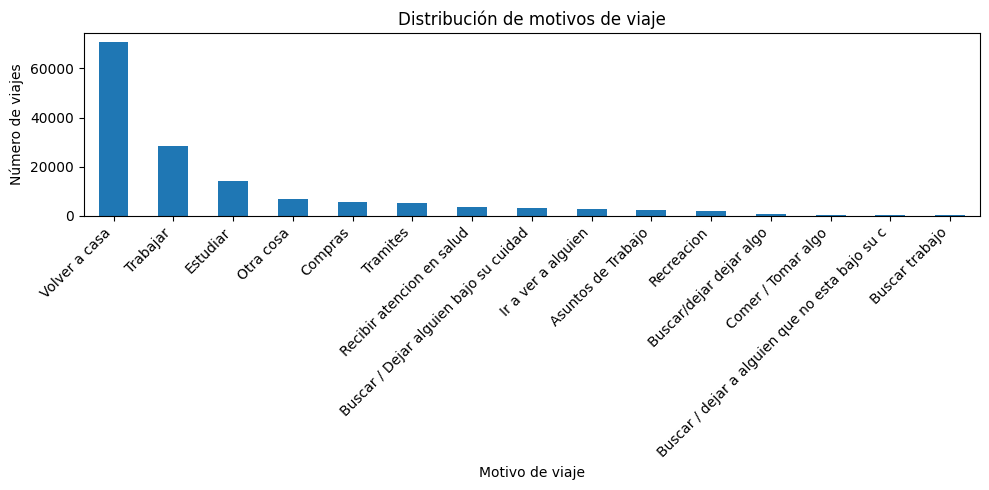

In [ ]:
import matplotlib.pyplot as plt

# Conteo de viajes por motivo
motivos_cnt = df["MOTIVOVIAJE"].value_counts().sort_values(ascending=False)
print("Frecuencia de motivos de viaje:")
print(motivos_cnt)

# Porcentaje de viajes por motivo
motivos_pct = df["MOTIVOVIAJE"].value_counts(normalize=True).sort_values(ascending=False) * 100
print("\nPorcentaje de viajes por motivo (%):")
print(motivos_pct.round(2))

# Gráfico de barras de los motivos
plt.figure(figsize=(10,5))
motivos_cnt.plot(kind="bar")
plt.title("Distribución de motivos de viaje")
plt.xlabel("Motivo de viaje")
plt.ylabel("Número de viajes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


- Se nalizará la distribución de modos de transporte predominantes en el conjunto de datos de viajes, calculando frecuencias, porcentajes y visualizando con un gráfico de barras horizontales.

Frecuencia de modos de transporte:
MEDIO_PREDOMINANTE
PEATON                            49313
TPC-SITP                          28653
Transmilenio                      16952
AUTO                              15932
BICICLETA, BICICLETA CON MOTOR     9260
ESPECIAL                           7097
MOTO                               6849
INTERMUNICIPAL                     5841
TAXI                               4619
ALIMENTADOR                        1075
ILEGAL                              916
OTROS                               744
Name: count, dtype: int64

Porcentaje de viajes por modo (%):
MEDIO_PREDOMINANTE
PEATON                            33.49
TPC-SITP                          19.46
Transmilenio                      11.51
AUTO                              10.82
BICICLETA, BICICLETA CON MOTOR     6.29
ESPECIAL                           4.82
MOTO                               4.65
INTERMUNICIPAL                     3.97
TAXI                               3.14
ALIMENTADOR              

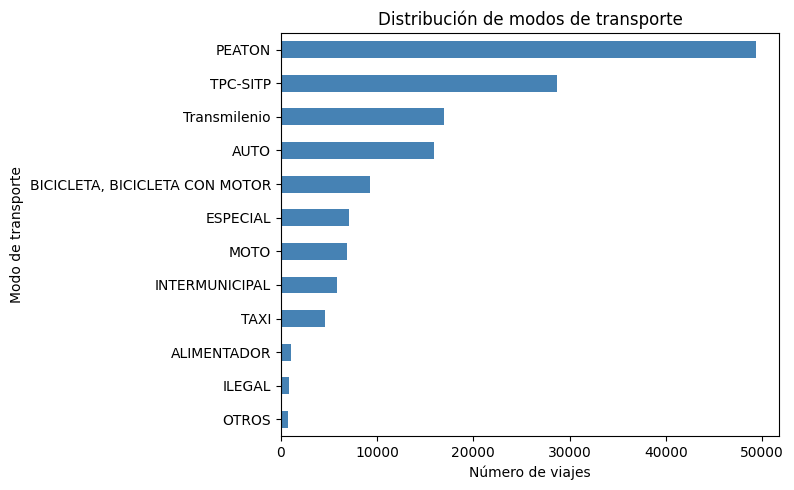

In [ ]:
# Conteo de viajes por modo de transporte
modos_cnt = df["MEDIO_PREDOMINANTE"].value_counts().sort_values(ascending=False)
print("Frecuencia de modos de transporte:")
print(modos_cnt)

# Porcentaje de viajes por modo
modos_pct = df["MEDIO_PREDOMINANTE"].value_counts(normalize=True).sort_values(ascending=False) * 100
print("\nPorcentaje de viajes por modo (%):")
print(modos_pct.round(2))

# Gráfico de barras horizontales
plt.figure(figsize=(8,5))
modos_cnt.plot(kind="barh", color="steelblue")
plt.title("Distribución de modos de transporte")
plt.xlabel("Número de viajes")
plt.ylabel("Modo de transporte")
plt.gca().invert_yaxis()  # modo más frecuente arriba
plt.tight_layout()
plt.show()


- Se generan dos diagramas de cajas donde el primer diagrama de cajas simple muestra el rango completo de TIEMPO_CAMINO , El segundo boxplot aplica automáticamente el método Tukey (1.5×IQR), restringiendo los bigotes y ocultando valores extremos, lo que produce una representación más conservadora con caja similar pero bigotes más cortos, ideal para exploración rápida.


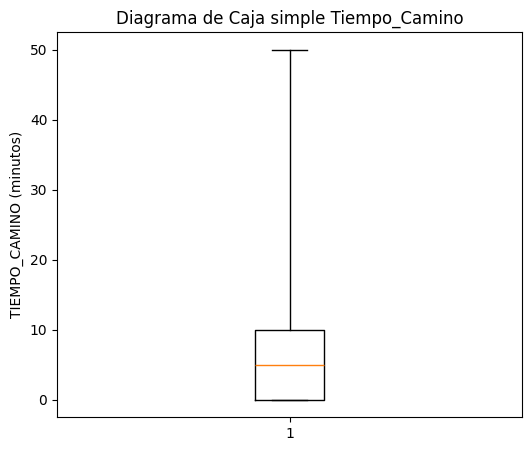

Mínimo : 0.0
Q1     : 0.0
Mediana: 5.0
Q3     : 10.0
Máximo : 50.0


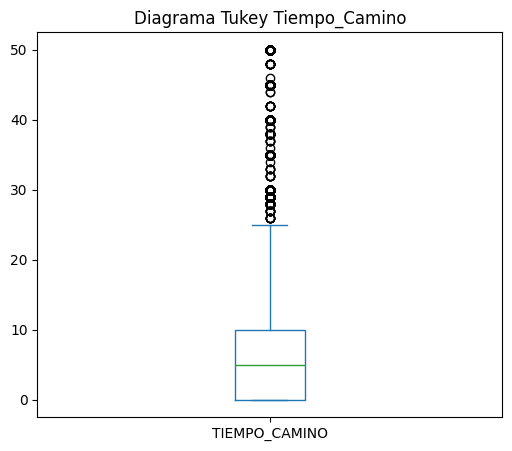

In [ ]:
x = df["TIEMPO_CAMINO"].dropna()

# Se calcula cinco números: min, Q1, mediana, Q3, max
minimo   = x.min()
q1       = x.quantile(0.25)
mediana  = x.median()
q3       = x.quantile(0.75)
maximo   = x.max()

#Se construye boxplot usando esos valores como referencia
plt.figure(figsize=(6,5))
plt.boxplot(
    x,
    vert=True,
    whis=(0, 100),
    showfliers=False
)
plt.ylabel("TIEMPO_CAMINO (minutos)")
plt.title("Diagrama de Caja simple Tiempo_Camino")
plt.show()

print("Mínimo :", minimo)
print("Q1     :", q1)
print("Mediana:", mediana)
print("Q3     :", q3)
print("Máximo :", maximo)


plt.figure(figsize=(6,5))
df["TIEMPO_CAMINO"].plot(kind="box")
plt.title("Diagrama Tukey Tiempo_Camino")
plt.show()


- Se generaran cuatro gráficas para analizar TIEMPO_CAMINO por MEDIO_PREDOMINANTE y hora de inicio.

1. Primer gráfico : Un diagrama de cajas horizontal que mostrará la distribución completa de tiempos por cada modo de transporte

2. Segundo gráfico : La barra horizontal de promedios ordenará los modos desde los más rápido hasta más lentos,

2. Tercer gráfico : El scatter general  revelará la densidad horaria total, con nube principal entre 10-30 minutos y dispersión creciente en horas valle.

4. Cuarto gráfico : El scatter filtrado (PEATON/TPC-SITP/AUTO, muestra 10% si >20k filas) comparará perfiles horarios diferenciados: PEATON constante, SITP con picos matutinos, AUTO más variable por tráfico.




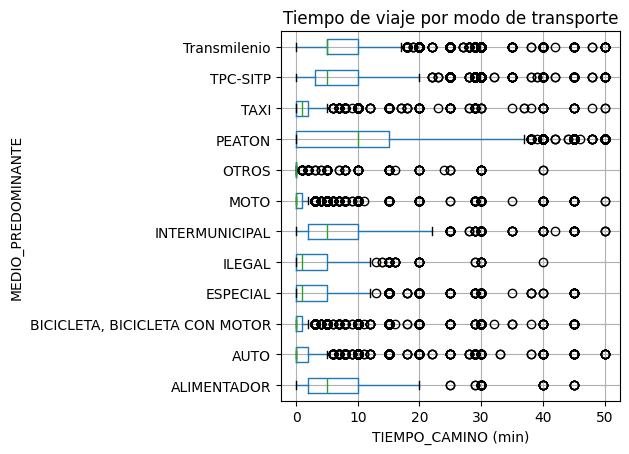

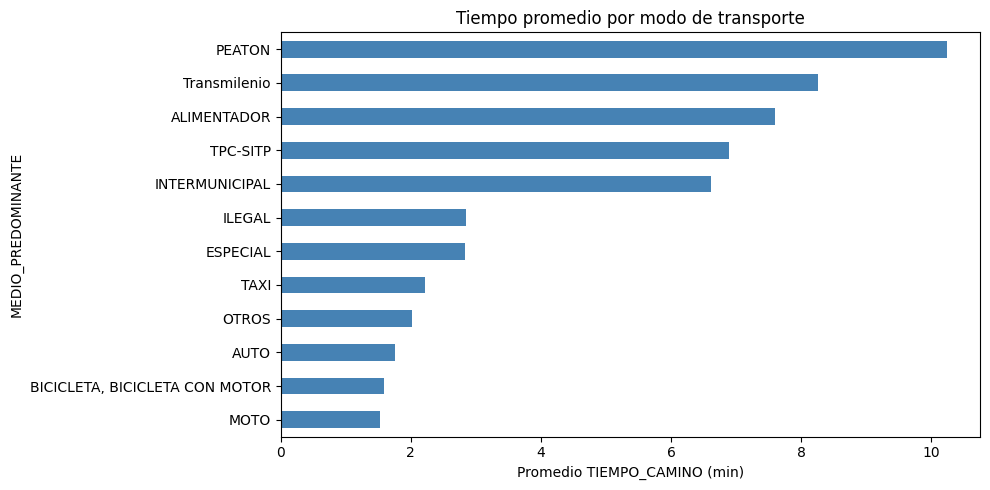

Filas base para scatter: 143133


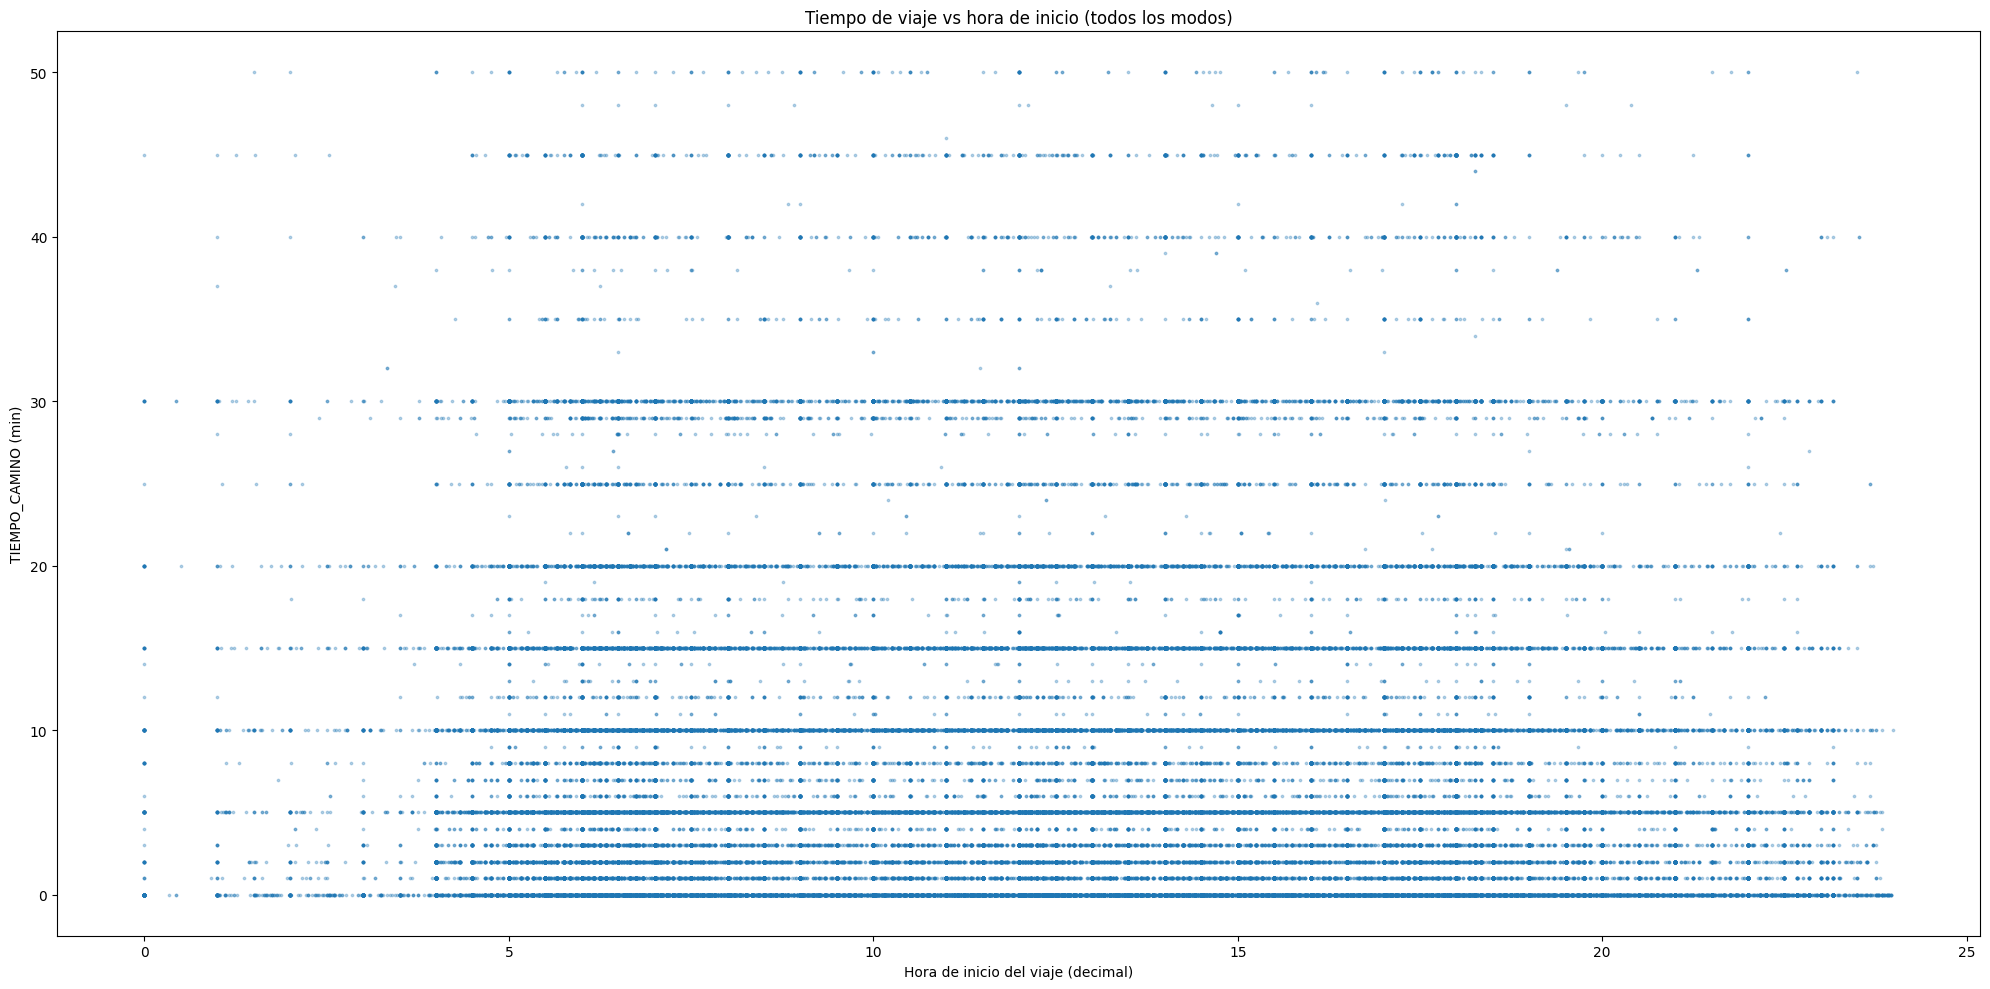


Algunos valores de MEDIO_PREDOMINANTE:
MEDIO_PREDOMINANTE
PEATON                            47070
TPC-SITP                          28082
Transmilenio                      16702
AUTO                              15708
BICICLETA, BICICLETA CON MOTOR     8978
ESPECIAL                           6994
MOTO                               6738
INTERMUNICIPAL                     5692
TAXI                               4552
ALIMENTADOR                        1050
ILEGAL                              896
OTROS                               671
Name: count, dtype: int64
Filas después de filtrar modos: 90860


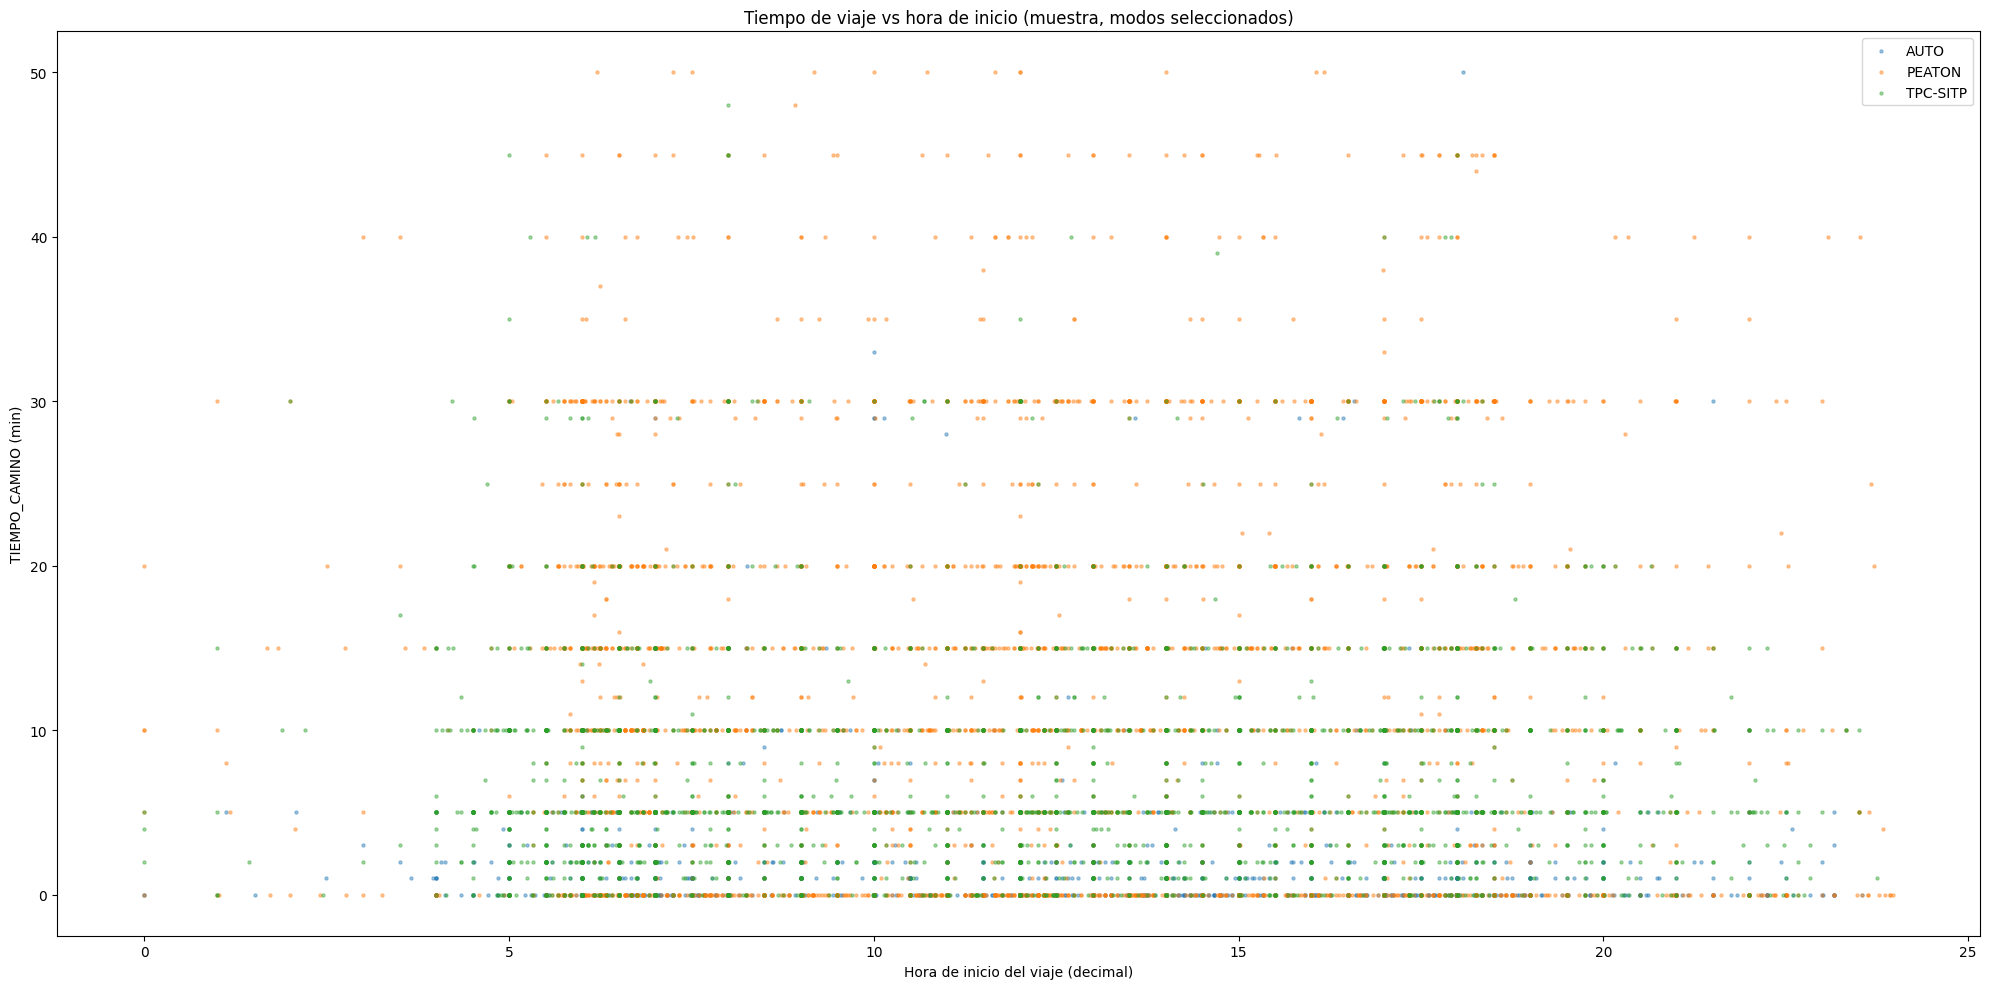

In [ ]:

df.boxplot(column='TIEMPO_CAMINO', by='MEDIO_PREDOMINANTE', vert=False)
plt.xlabel('TIEMPO_CAMINO (min)')
plt.ylabel('MEDIO_PREDOMINANTE')
plt.title('Tiempo de viaje por modo de transporte')
plt.suptitle('')
plt.tight_layout()
plt.show()


mean_mode = (
    df.groupby('MEDIO_PREDOMINANTE')['TIEMPO_CAMINO']
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,5))
mean_mode.plot(kind='barh', color='steelblue')
plt.xlabel('Promedio TIEMPO_CAMINO (min)')
plt.ylabel('MEDIO_PREDOMINANTE')
plt.title('Tiempo promedio por modo de transporte')
plt.tight_layout()
plt.show()

df['HORAINICIO_DT'] = pd.to_datetime(df['HORA_INICIO'], format='%H:%M:%S', errors='coerce')


base = df.dropna(subset=['TIEMPO_CAMINO', 'HORAINICIO_DT']).copy()
base['HORA_DEC'] = (
    base['HORAINICIO_DT'].dt.hour
    + base['HORAINICIO_DT'].dt.minute/60
)

print("Filas base para scatter:", len(base))

plt.figure(figsize=(20,10))
plt.scatter(base['HORA_DEC'], base['TIEMPO_CAMINO'],
            s=3, alpha=0.3)
plt.xlabel('Hora de inicio del viaje (decimal)')
plt.ylabel('TIEMPO_CAMINO (min)')
plt.title('Tiempo de viaje vs hora de inicio (todos los modos)')
plt.tight_layout()
plt.show()


print("\nAlgunos valores de MEDIO_PREDOMINANTE:")
print(base['MEDIO_PREDOMINANTE'].value_counts().head(15))

modos_mostrar = ['PEATON', 'TPC-SITP', 'AUTO']

f = base[base['MEDIO_PREDOMINANTE'].isin(modos_mostrar)]
print("Filas después de filtrar modos:", len(f))

if len(f) > 0:
    f_plot = f.sample(frac=0.1, random_state=0) if len(f) > 20000 else f

    plt.figure(figsize=(20,10))
    for modo, sub in f_plot.groupby('MEDIO_PREDOMINANTE'):
        plt.scatter(sub['HORA_DEC'], sub['TIEMPO_CAMINO'],
                    s=5, alpha=0.4, label=modo)

    plt.xlabel('Hora de inicio del viaje (decimal)')
    plt.ylabel('TIEMPO_CAMINO (min)')
    plt.title('Tiempo de viaje vs hora de inicio (muestra, modos seleccionados)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No hay filas con los modos indicados; revisa los nombres impresos arriba.")
